# 🐷 Pig Posture Recognition – Inference & Submission

Generates a competition-ready CSV from a trained checkpoint.  
Supports **Test-Time Augmentation (TTA)** and **multi-checkpoint ensembling**.

**Run this notebook after `train.ipynb` is complete.**

## ⚙️ Configuration

In [13]:
# ──────────────────────────────────────────────────────────────────────────────
# CONFIGURATION  (edit before running)
# ──────────────────────────────────────────────────────────────────────────────

# T1 or T2 – determines the required submission name prefix
TAG = "T2"

DATA_ROOT = "/datasets/multi-view-pig-posture-recognition"
TEST_CSV  = f"{DATA_ROOT}/test.csv"
IMG_DIR   = f"{DATA_ROOT}/test_images"

# One or more checkpoint paths (multiple = ensemble)
CKPT_PATHS = [
    f"runs/{TAG.lower()}/best_model.pth",
    # "runs/t1/checkpoint_epoch35.pth",  # add more for ensembling
]

OUTPUT_FILE  = f"{TAG}_submission.csv"   # MUST start with T1_ or T2_
BATCH_SIZE   = 64
NUM_WORKERS  = 8
USE_TTA      = True    # Test-Time Augmentation (slower but better accuracy)
PAD_RATIO    = 0.15    # must match training setting

NUM_CLASSES  = 5
CLASS_NAMES  = ["Lateral_lying_left", "Lateral_lying_right",
                "Sitting", "Standing", "Sternal_lying"]
IMG_SIZE     = 224

print(f"Tag: {TAG}  |  Output: {OUTPUT_FILE}  |  TTA: {USE_TTA}")
print(f"Checkpoints: {CKPT_PATHS}")

Tag: T2  |  Output: T2_submission.csv  |  TTA: True
Checkpoints: ['runs/t2/best_model.pth']


## 📚 Imports

In [14]:
import os, ast
import numpy as np
import pandas as pd
from PIL import Image
from tqdm.notebook import tqdm

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torch.cuda.amp import autocast
import torchvision.transforms as T
import timm

import warnings
warnings.filterwarnings("ignore")

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {DEVICE}")
if DEVICE.type == "cuda":
    print(f"GPU: {torch.cuda.get_device_name(0)}")

Device: cuda
GPU: Tesla V100-SXM2-32GB


## 🗂️ Test Dataset

In [15]:
class PigTestDataset(Dataset):
    """Crops pig instances from full frames using provided bounding boxes."""

    def __init__(self, df, img_dir, transform=None, pad_ratio=0.15):
        self.df        = df.reset_index(drop=True)
        self.img_dir   = img_dir
        self.transform = transform
        self.pad_ratio = pad_ratio

    def __len__(self): return len(self.df)

    def _crop(self, img, bbox):
        W, H = img.size
        x, y, w, h = [float(v) for v in ast.literal_eval(bbox)]
        px, py = w * self.pad_ratio, h * self.pad_ratio
        x1 = max(0, int(x - px));  y1 = max(0, int(y - py))
        x2 = min(W, int(x+w+px)); y2 = min(H, int(y+h+py))
        return img.crop((x1, y1, x2, y2))

    def __getitem__(self, idx):
        row  = self.df.iloc[idx]
        img  = Image.open(os.path.join(self.img_dir, row["image_id"])).convert("RGB")
        crop = self._crop(img, row["bbox"])
        if self.transform: crop = self.transform(crop)
        return crop, row["row_id"]


# TTA: 4 augmented views (original, h-flip, zoom, zoom+h-flip)
TTA_TRANSFORMS = [
    T.Compose([T.Resize((IMG_SIZE, IMG_SIZE)),
               T.ToTensor(), T.Normalize([0.485,0.456,0.406],[0.229,0.224,0.225])]),
    T.Compose([T.Resize((IMG_SIZE, IMG_SIZE)), T.RandomHorizontalFlip(p=1.0),
               T.ToTensor(), T.Normalize([0.485,0.456,0.406],[0.229,0.224,0.225])]),
    T.Compose([T.Resize((IMG_SIZE+32, IMG_SIZE+32)), T.CenterCrop(IMG_SIZE),
               T.ToTensor(), T.Normalize([0.485,0.456,0.406],[0.229,0.224,0.225])]),
    T.Compose([T.Resize((IMG_SIZE+32, IMG_SIZE+32)), T.CenterCrop(IMG_SIZE),
               T.RandomHorizontalFlip(p=1.0),
               T.ToTensor(), T.Normalize([0.485,0.456,0.406],[0.229,0.224,0.225])]),
]

BASE_TRANSFORM = TTA_TRANSFORMS[0]

print("Test dataset and transforms defined.")

Test dataset and transforms defined.


## 📂 Load Test Data & Models

In [16]:
test_df = pd.read_csv(TEST_CSV)
print(f"Test instances: {len(test_df)}")
print(f"Unique images:  {test_df['image_id'].nunique()}")
test_df.head(3)

Test instances: 11708
Unique images:  1350


,row_id,image_id,width,height,bbox
0,test_pen1_tur_cam1_20250920_174649_0000,pen1_tur_cam1_20250920_174649.jpg,1280,720,"[432.0,291.0,306.0,394.0]"
1,test_pen1_tur_cam1_20250920_174649_0001,pen1_tur_cam1_20250920_174649.jpg,1280,720,"[237.0,254.0,246.0,402.0]"
2,test_pen1_tur_cam1_20250920_174649_0002,pen1_tur_cam1_20250920_174649.jpg,1280,720,"[742.5,387.0,235.0,258.0]"


## 🔮 Run Inference

In [17]:
@torch.no_grad()
def predict_tta(model, df, img_dir, transforms):
    """Returns softmax probabilities averaged over all TTA views. Shape: (N, C)"""
    all_view_probs = []
    for i, tf in enumerate(transforms):
        ds     = PigTestDataset(df, img_dir, transform=tf, pad_ratio=PAD_RATIO)
        loader = DataLoader(ds, batch_size=BATCH_SIZE, shuffle=False,
                            num_workers=NUM_WORKERS, pin_memory=True)
        probs_list = []
        for imgs, _ in tqdm(loader, desc=f"  TTA {i+1}/{len(transforms)}", leave=False):
            imgs = imgs.to(DEVICE)
            with autocast():
                logits = model(imgs)
            probs_list.append(F.softmax(logits, dim=1).cpu().numpy())
        all_view_probs.append(np.vstack(probs_list))
    return np.mean(all_view_probs, axis=0)   # average over views


# ── Predict with each checkpoint, then ensemble ───────────────────────────────
transforms = TTA_TRANSFORMS if USE_TTA else [BASE_TRANSFORM]
ensemble_probs = []

for ckpt_path in CKPT_PATHS:
    print(f"\nLoading checkpoint: {ckpt_path}")
    ckpt       = torch.load(ckpt_path, map_location="cpu")
    model_name = ckpt.get("model_name", "efficientnet_b4")
    val_f1     = ckpt.get("val_f1", float("nan"))
    print(f"  Model: {model_name}  |  Best Val F1: {val_f1:.4f}")

    model = timm.create_model(model_name, pretrained=False, num_classes=NUM_CLASSES)
    model.load_state_dict(ckpt["model"])
    model.to(DEVICE).eval()

    probs = predict_tta(model, test_df, IMG_DIR, transforms)
    ensemble_probs.append(probs)
    del model
    torch.cuda.empty_cache()

final_probs  = np.mean(ensemble_probs, axis=0)   # (N, 5)
predictions  = final_probs.argmax(axis=1)         # (N,)
print(f"\n✓ Inference complete for {len(predictions)} instances")


Loading checkpoint: runs/t2/best_model.pth
  Model: efficientnet_b4  |  Best Val F1: 0.8996


  TTA 1/4:   0%|          | 0/183 [00:00<?, ?it/s]

  TTA 2/4:   0%|          | 0/183 [00:00<?, ?it/s]

  TTA 3/4:   0%|          | 0/183 [00:00<?, ?it/s]

  TTA 4/4:   0%|          | 0/183 [00:00<?, ?it/s]


✓ Inference complete for 11708 instances


## 📄 Build & Save Submission CSV

In [18]:
submission = pd.DataFrame({
    "row_id":   test_df["row_id"].values,
    "class_id": predictions.astype(int),
})

submission.to_csv(OUTPUT_FILE, index=False)
print(f"✓ Submission saved → {OUTPUT_FILE}  ({len(submission)} rows)")

# ── Sanity checks ─────────────────────────────────────────────────────────────
assert list(submission.columns) == ["row_id", "class_id"], "Column order wrong!"
assert set(submission["class_id"].unique()).issubset(set(range(5))), "Invalid class_id!"
assert submission["row_id"].is_unique, "Duplicate row_ids!"
assert len(submission) == len(test_df), "Row count mismatch!"
assert OUTPUT_FILE.startswith(("T1_", "T2_")), "Filename must start with T1_ or T2_!"
print("✓ All sanity checks passed")

✓ Submission saved → T2_submission.csv  (11708 rows)
✓ All sanity checks passed


## 📊 Prediction Analysis

Predicted class distribution:
  0 - Lateral_lying_left     ███                             1295  (11.1%)
  1 - Lateral_lying_right    ██                               800  (6.8%)
  2 - Sitting                ██                              1156  (9.9%)
  3 - Standing               ███████████████                 6183  (52.8%)
  4 - Sternal_lying          █████                           2274  (19.4%)


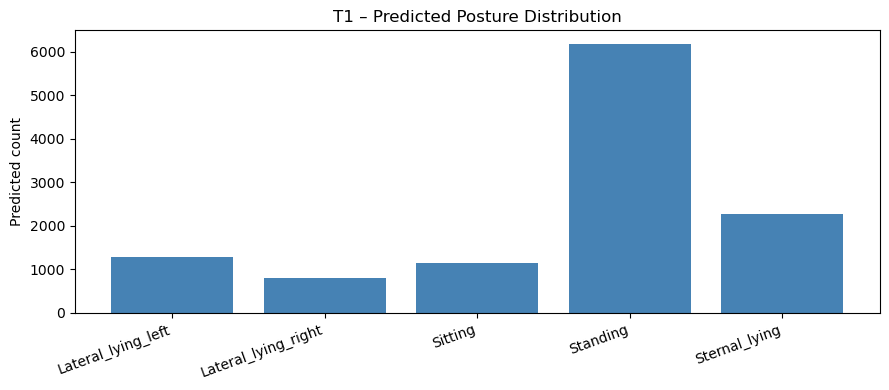


Preview of submission file:


,row_id,class_id
0,test_pen1_tur_cam1_20250920_174649_0000,3
1,test_pen1_tur_cam1_20250920_174649_0001,1
2,test_pen1_tur_cam1_20250920_174649_0002,0
3,test_pen1_tur_cam1_20250920_174649_0003,3
4,test_pen1_tur_cam1_20250920_174649_0004,0
5,test_pen1_tur_cam1_20250920_174649_0005,1
6,test_pen1_tur_cam1_20250920_174649_0006,0
7,test_pen1_tur_cam1_20250920_174649_0007,1
8,test_pen1_tur_cam1_20250920_174649_0008,3
9,test_pen1_tur_cam1_20250921_050022_0000,0


In [12]:
import matplotlib.pyplot as plt

print("Predicted class distribution:")
counts = submission["class_id"].value_counts().sort_index()
for c in range(NUM_CLASSES):
    cnt = counts.get(c, 0)
    bar = "█" * int(30 * cnt / len(submission))
    print(f"  {c} - {CLASS_NAMES[c]:<22} {bar:<30} {cnt:>5}  ({100*cnt/len(submission):.1f}%)")

# Bar chart
fig, ax = plt.subplots(figsize=(9, 4))
ax.bar(range(NUM_CLASSES), [counts.get(c, 0) for c in range(NUM_CLASSES)], color="steelblue")
ax.set_xticks(range(NUM_CLASSES))
ax.set_xticklabels(CLASS_NAMES, rotation=20, ha="right")
ax.set_ylabel("Predicted count")
ax.set_title(f"{TAG} – Predicted Posture Distribution")
plt.tight_layout()
plt.show()

print(f"\nPreview of submission file:")
submission.head(10)